In [1]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 4.1 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 4.5 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [statsmodels] [statsmodels]


Gathering actor-level data across all snapshots...
[SUCCESS] Dataset grezzo creato: 41829 osservazioni.

Applying data transformations and sample balancing...
[SUCCESS] Bilanciamento completato.
Campione finale bilanciato: 30448 osservazioni.
Distribuzione di genere finale:
Gender
F    15224
M    15224
Name: count, dtype: int64

Running Ordinary Least Squares (OLS) Regression on Transformed & Balanced Data...
                            OLS Regression Results                            
Dep. Variable:             Log_Degree   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     264.0
Date:                Wed, 27 May 2026   Prob (F-statistic):          2.03e-223
Time:                        10:12:11   Log-Likelihood:                -30805.
No. Observations:               30448   AIC:                         6.162e+04
Df Residuals:                   30

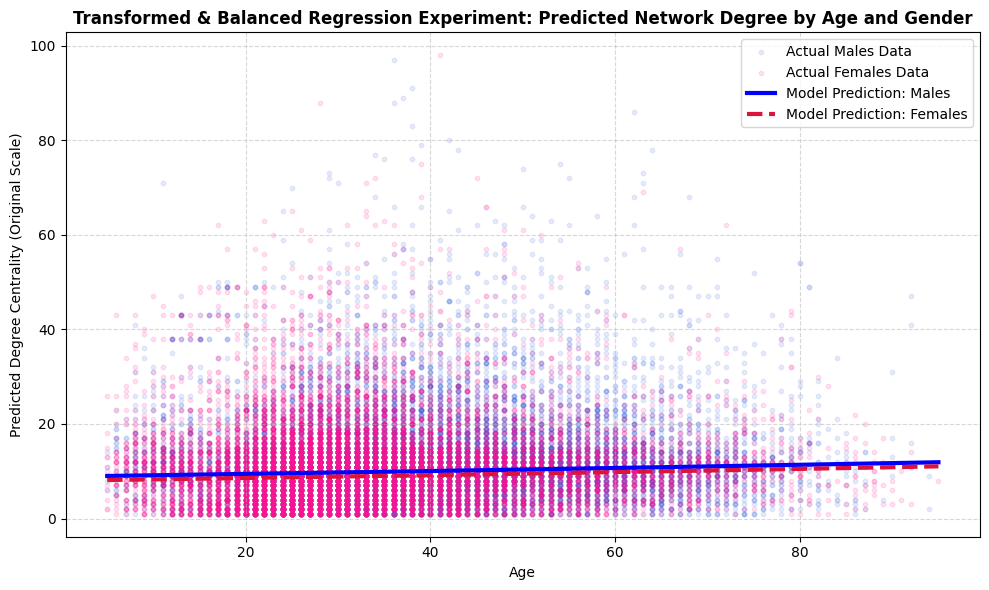

In [5]:
import os
import pickle
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ===========================================================================
# 1. PERCORSI DEI DATI & ESTRAZIONE GREZZA
# ===========================================================================
input_dir = "data/processed/actor_projections"
all_actors_data = []

print("Gathering actor-level data across all snapshots...")

for filename in sorted(os.listdir(input_dir)):
    if filename.endswith(".pkl") and "actors_projected_" in filename:
        year = int(filename.split("_")[2].split(".")[0])
        file_path = os.path.join(input_dir, filename)
        
        with open(file_path, 'rb') as f:
            g = pickle.load(f)
            
        g_clean = g.subgraph(g.vs.select(_degree_gt=0))
        if g_clean.vcount() == 0:
            continue
            
        genders = g_clean.vs["gender"]
        ages = [int(age) if age is not None and str(age).isdigit() else np.nan for age in g_clean.vs["age"]]
        degrees = g_clean.degree()
        betweenness = g_clean.betweenness()
        
        for i in range(g_clean.vcount()):
            if not np.isnan(ages[i]):
                all_actors_data.append({
                    "Year": year,
                    "Name": g_clean.vs[i]["name"],
                    "Gender": genders[i],
                    "Is_Female": 1 if genders[i] == "F" else 0,
                    "Age": ages[i],
                    "Degree": degrees[i],
                    "Betweenness": betweenness[i]
                })

# Creazione DataFrame iniziale
df_raw = pd.DataFrame(all_actors_data)
print(f"[SUCCESS] Dataset grezzo creato: {len(df_raw)} osservazioni.")

# ===========================================================================
# 2. DATA PREPARATION, TRANSFORMATIONS & BALANCING (AGGIORNATO)
# ===========================================================================
print("\nApplying data transformations and sample balancing...")

# A. Filtraggio Outlier iniziale (età plausibili)
df_clean = df_raw[(df_raw["Age"] >= 5) & (df_raw["Age"] <= 100)].copy()

# B. BILANCIAMENTO ESATTO (Downsampling anno per anno)
# Garantisce che il numero di uomini e donne sia identico in ogni snapshot temporale
balanced_records = []
np.random.seed(42) # Fissiamo il seed per rendere l'esperimento replicabile

for year, group in df_clean.groupby("Year"):
    females = group[group["Gender"] == "F"]
    males = group[group["Gender"] == "M"]
    
    n_females = len(females)
    n_males = len(males)
    
    # Prendiamo il numero minimo tra i due gruppi per livellare il campione
    sample_size = min(n_females, n_males)
    
    if sample_size > 0:
        sampled_females = females.sample(n=sample_size)
        sampled_males = males.sample(n=sample_size)
        balanced_records.append(pd.concat([sampled_females, sampled_males]))

# Creiamo il nuovo DataFrame bilanciato
df_regression = pd.concat(balanced_records).reset_index(drop=True)

# C. Trasformazione Logaritmica del Degree (Target)
df_regression["Log_Degree"] = np.log1p(df_regression["Degree"])

# D. Centratura dell'Anno (Feature Rescaling)
df_regression["Years_Since_1986"] = df_regression["Year"] - 1986

print(f"[SUCCESS] Bilanciamento completato.")
print(f"Campione finale bilanciato: {len(df_regression)} osservazioni.")
print(f"Distribuzione di genere finale:\n{df_regression['Gender'].value_counts()}")

# ===========================================================================
# 3. L'ESPERIMENTO DI REGRESSIONE LINEARE (OLS SU DATI TRASFORMATI)
# ===========================================================================
formula = "Log_Degree ~ Age * Is_Female + Years_Since_1986"

print("\nRunning Ordinary Least Squares (OLS) Regression on Transformed & Balanced Data...")
model = smf.ols(formula=formula, data=df_regression).fit()
print(model.summary())

# ===========================================================================
# 4. VISUALIZZAZIONE DEI RISULTATI DELL'ESPERIMENTO
# ===========================================================================
plt.figure(figsize=(10, 6), facecolor='white')

age_range = np.linspace(df_regression["Age"].min(), df_regression["Age"].max(), 100)
mean_years_scaled = df_regression["Years_Since_1986"].mean()

# Estrazione dei nuovi parametri basati sul modello logaritmico e bilanciato
c_intercept = model.params['Intercept']
c_age = model.params['Age']
c_female = model.params['Is_Female']
c_interaction = model.params['Age:Is_Female']
c_year_scaled = model.params['Years_Since_1986']

# Calcolo delle predizioni in scala logaritmica
log_pred_males = c_intercept + (c_age * age_range) + (c_year_scaled * mean_years_scaled)
log_pred_females = (c_intercept + c_female) + ((c_age + c_interaction) * age_range) + (c_year_scaled * mean_years_scaled)

# Riconvertiamo le predizioni nella scala originale del Degree
pred_males = np.expm1(log_pred_males)
pred_females = np.expm1(log_pred_females)

# Disegno dello scatter plot di sfondo
plt.scatter(df_regression[df_regression["Gender"]=="M"]["Age"], df_regression[df_regression["Gender"]=="M"]["Degree"], 
            color='royalblue', alpha=0.12, s=10, label='Actual Males Data')
plt.scatter(df_regression[df_regression["Gender"]=="F"]["Age"], df_regression[df_regression["Gender"]=="F"]["Degree"], 
            color='deeppink', alpha=0.12, s=10, label='Actual Females Data')

# Disegno delle curve predittive
plt.plot(age_range, pred_males, color='blue', linewidth=3, label='Model Prediction: Males')
plt.plot(age_range, pred_females, color='crimson', linewidth=3, linestyle='--', label='Model Prediction: Females')

plt.title("Transformed & Balanced Regression Experiment: Predicted Network Degree by Age and Gender", fontsize=12, fontweight='bold')
plt.xlabel("Age", fontsize=10)
plt.ylabel("Predicted Degree Centrality (Original Scale)", fontsize=10)
plt.legend()
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()